   Simulation   best_age_group  p_subgroup   p_total  p_hacked
0           1     (17.0, 41.0]    0.171791  0.221115     False
1           2   (-0.001, 17.0]    0.120925  0.051177     False
2           3     (63.0, 80.0]    0.078832  0.042752     False
3           4     (36.0, 61.0]    0.702646  0.944589     False
4           5     (15.0, 40.0]    0.009815  0.264147      True
5           6     (66.0, 80.0]    0.066598  0.076821     False
6           7     (40.0, 64.0]    0.083468  0.145125     False
7           8     (41.0, 64.0]    0.050093  0.034140     False
8           9     (17.0, 44.0]    0.043101  0.000123     False
9          10  (-0.001, 15.75]    0.008204  0.099694      True


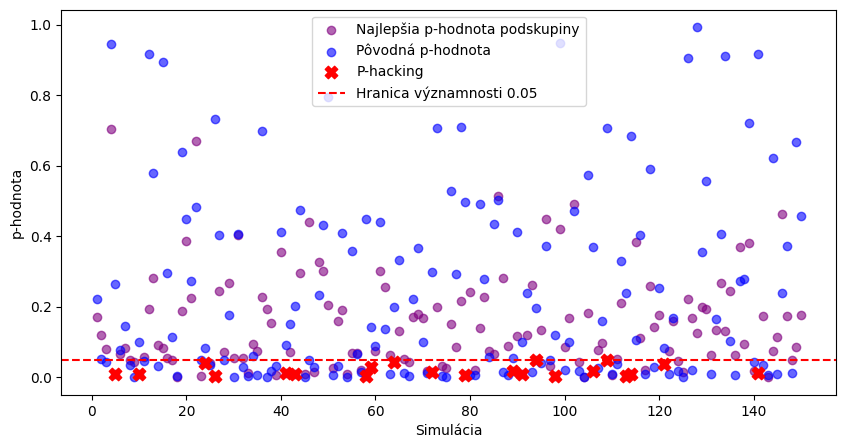

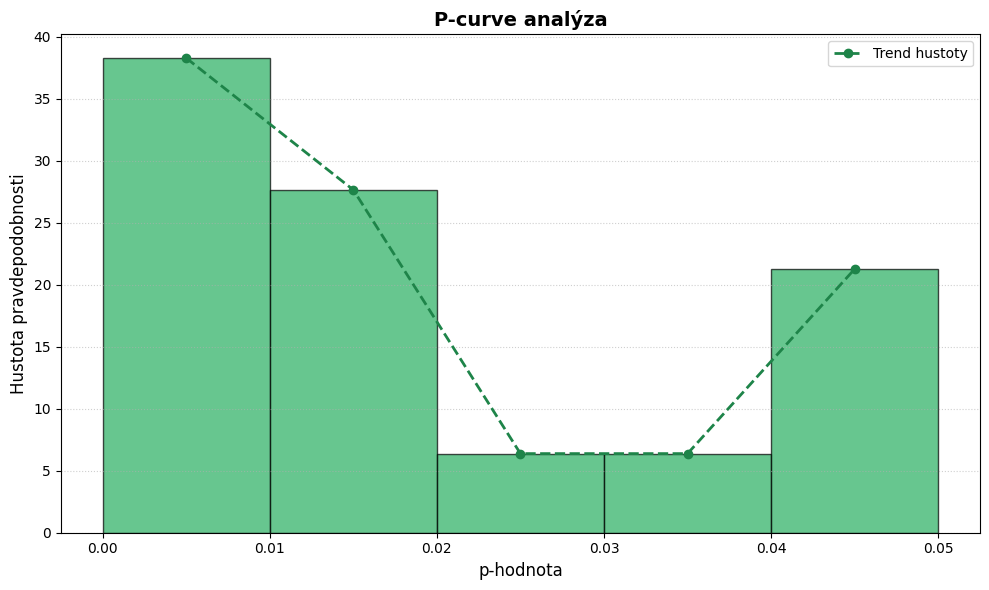

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import sys, os
import warnings
sys.path.append(os.path.abspath(".."))
import settings

# Ignorovanie warningov
warnings.filterwarnings("ignore")

# nacitanie suborov
def load_file(file_path):
    return pd.read_sas(file_path, format='xport')

def merge_files(file1, file2):
    return pd.merge(file1, file2[['SEQN','RIDAGEYR','RIAGENDR']], on='SEQN', how='left')

bmx = load_file(settings.bmx_path)
demo = load_file(settings.demo_path)
data = merge_files(bmx, demo)

# premapovanie pohlavia na text
data['gender_label'] = data['RIAGENDR'].map({1:"Men", 2:"Women"})

# parametre simulacie
dependent_var = 'BMXBMI'
sample_size = 400
n_sim = 150
alpha = 0.05
n_subgroups = 4  # počet podskupín podľa veku

# simulacia
results = []

for sim in range(n_sim):
    # náhodný výber vzorky
    sample = data.sample(sample_size, random_state=sim)
    
    # vytvorenie vekových podskupín (kvartily)
    sample['age_group'] = pd.qcut(sample['RIDAGEYR'], q=n_subgroups, duplicates='drop')

    best_p = np.nan
    best_group = None

    # pre každú vekovú podskupinu robíme t-test medzi mužmi a ženami
    for grp, grp_data in sample.groupby('age_group'):
        # výber BMI pre mužov a ženy
        men = grp_data[grp_data['gender_label']=='Men'][dependent_var].dropna()
        women = grp_data[grp_data['gender_label']=='Women'][dependent_var].dropna()

        # test robíme len ak máme dostatok dát
        if len(men) > 1 and len(women) > 1:
            t_stat, p_val = stats.ttest_ind(men, women)
             # uložíme najmenšiu p-hodnotu
            if np.isnan(best_p) or p_val < best_p:
                best_p = p_val
                best_group = grp

    # férový t-test na celej vzorke
    men_total = sample[sample['gender_label']=='Men'][dependent_var].dropna()
    women_total = sample[sample['gender_label']=='Women'][dependent_var].dropna()
    if len(men_total) > 1 and len(women_total) > 1:
        _, p_total = stats.ttest_ind(men_total, women_total)
    else:
        p_total = np.nan

    # indikátor p-hackingu
    p_hacked = (best_p <= alpha) and (p_total > alpha)

     # uloženie výsledkov simulácie
    results.append({
        "Simulation": sim+1,
        "best_age_group": str(best_group),
        "p_subgroup": best_p,
        "p_total": p_total,
        "p_hacked": p_hacked
    })

df = pd.DataFrame(results)
df.to_csv("phacking_groups.csv", index=False)

# Výpis tabuľky prvých 10 simulácií
print(df.head(10))

# Graf p-hodnôt 
plt.figure(figsize=(10,5))
plt.scatter(df['Simulation'], df['p_subgroup'], alpha=0.6, label='Najlepšia p-hodnota podskupiny', color='purple')
plt.scatter(df['Simulation'], df['p_total'], alpha=0.6, label='Pôvodná p-hodnota', color='blue')

# Hacknuté simulácie
plt.scatter(df.loc[df['p_hacked'], 'Simulation'],
            df.loc[df['p_hacked'], 'p_subgroup'],
            color='red', s=80, label='P-hacking', marker='X')

plt.axhline(alpha, color='red', linestyle='--', label='Hranica významnosti 0.05')
plt.xlabel('Simulácia')
plt.ylabel('p-hodnota')
plt.legend()
plt.savefig("phacking_groups.png",dpi=300)
plt.show()

# P-curve analýza

# vyberieme len signifikantné hodnoty z podskupín
sig_p_groups = df[df['p_subgroup'] < 0.05]['p_subgroup'].dropna()

if len(sig_p_groups) > 0:
    plt.figure(figsize=(10, 6))
    
    # Histogram hustoty
    counts, bins, _ = plt.hist(sig_p_groups, bins=5, range=(0, 0.05), 
                               color='#27ae60', edgecolor='black', alpha=0.7, density=True)
    
    # Trendová čiara (
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    plt.plot(bin_centers, counts, color='#1e8449', marker='o', linestyle='--', linewidth=2, label='Trend hustoty')

    plt.title('P-curve analýza', fontsize=14, fontweight='bold')
    plt.xlabel('p-hodnota', fontsize=12)
    plt.ylabel('Hustota pravdepodobnosti', fontsize=12)
    plt.xticks(np.arange(0, 0.06, 0.01))
    plt.grid(axis='y', linestyle=':', alpha=0.6)
    plt.legend()

    plt.tight_layout()
    plt.savefig("pcurve_groups.png", dpi=300)
    plt.show()